In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving big_tech_stock_prices.csv to big_tech_stock_prices.csv
Saving big_tech_companies.csv to big_tech_companies.csv


In [ ]:
companies_df = pd.read_csv('big_tech_companies.csv')
prices_df    = pd.read_csv('big_tech_stock_prices.csv')

print('=== Companies ===' )
print(companies_df)
print(f'\n=== Stock Prices ===')
print(f'Shape: {prices_df.shape}')
print(prices_df.head())

=== Companies ===
   stock_symbol                                      company
0          AAPL                                   Apple Inc.
1          ADBE                                   Adobe Inc.
2          AMZN                             Amazon.com, Inc.
3           CRM                             Salesforce, Inc.
4          CSCO                          Cisco Systems, Inc.
5         GOOGL                                Alphabet Inc.
6           IBM  International Business Machines Corporation
7          INTC                            Intel Corporation
8          META                         Meta Platforms, Inc.
9          MSFT                        Microsoft Corporation
10         NFLX                                Netflix, Inc.
11         NVDA                           NVIDIA Corporation
12         ORCL                           Oracle Corporation
13         TSLA                                  Tesla, Inc.

=== Stock Prices ===
Shape: (45088, 8)
  stock_symbol        date 

In [ ]:
print('--- Data Types ---')
print(prices_df.dtypes)
print('\n--- Summary Statistics ---')
prices_df.describe()

--- Data Types ---
stock_symbol     object
date             object
open            float64
high            float64
low             float64
close           float64
adj_close       float64
volume            int64
dtype: object

--- Summary Statistics ---


,open,high,low,close,adj_close,volume
count,45088.0000,45088.0000,45088.0000,45088.0000,45088.0000,45088.0000
mean,89.2666,90.3698,88.1119,89.2713,85.2096,52978130.5376
std,101.6270,103.0011,100.1244,101.5929,100.9960,93247295.8729
min,1.0760,1.1087,0.9987,1.0533,1.0533,589200.0000
25%,25.6700,25.9301,25.3600,25.6600,22.0764,9629425.0000
50%,47.9300,48.4600,47.4650,47.9700,45.3773,26463150.0000
75%,128.6625,129.8489,127.2539,128.6406,113.6725,58397675.0000
max,696.2800,700.9900,686.0900,691.6900,691.6900,1880998000.0000


In [ ]:
print('--- Unique Tickers ---')
print(prices_df['stock_symbol'].unique())
print(f'\nTotal tickers: {prices_df["stock_symbol"].nunique()}')
print(f'Date range  : {prices_df["date"].min()}  →  {prices_df["date"].max()}')
print(f'\n--- Records per Ticker ---')
print(prices_df['stock_symbol'].value_counts().sort_index())

--- Unique Tickers ---
['AAPL' 'ADBE' 'AMZN' 'CRM' 'CSCO' 'GOOGL' 'IBM' 'INTC' 'META' 'MSFT'
 'NFLX' 'NVDA' 'ORCL' 'TSLA']

Total tickers: 14
Date range  : 2010-01-04  →  2023-01-24

--- Records per Ticker ---
stock_symbol
AAPL     3271
ADBE     3271
AMZN     3271
CRM      3271
CSCO     3271
GOOGL    3271
IBM      3271
INTC     3271
META     2688
MSFT     3271
NFLX     3271
NVDA     3271
ORCL     3271
TSLA     3148
Name: count, dtype: int64


In [ ]:
# Parse date column as datetime
prices_df['date'] = pd.to_datetime(prices_df['date'])

# Ensure numeric columns are float
numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']
prices_df[numeric_cols] = prices_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print('Data types after fix:')
print(prices_df.dtypes)

Data types after fix:
stock_symbol            object
date            datetime64[ns]
open                   float64
high                   float64
low                    float64
close                  float64
adj_close              float64
volume                   int64
dtype: object


In [ ]:
print('=== Missing Values per Column ===')
missing = prices_df.isnull().sum()
missing_pct = (missing / len(prices_df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

=== Missing Values per Column ===
              Missing Count  Missing %
stock_symbol              0     0.0000
date                      0     0.0000
open                      0     0.0000
high                      0     0.0000
low                       0     0.0000
close                     0     0.0000
adj_close                 0     0.0000
volume                    0     0.0000


In [ ]:
# Forward-fill within each ticker group (preserves temporal order)
prices_df = prices_df.sort_values(['stock_symbol', 'date']).reset_index(drop=True)
prices_df[numeric_cols] = (
    prices_df.groupby('stock_symbol')[numeric_cols]
    .transform(lambda x: x.ffill().bfill())
)

print('Missing values after imputation:')
print(prices_df.isnull().sum())

Missing values after imputation:
stock_symbol    0
date            0
open            0
high            0
low             0
close           0
adj_close       0
volume          0
dtype: int64


In [ ]:
before = len(prices_df)
prices_df = prices_df.drop_duplicates(subset=['stock_symbol', 'date'])
after  = len(prices_df)
print(f'Rows before: {before} | Rows after: {after} | Duplicates removed: {before - after}')

Rows before: 45088 | Rows after: 45088 | Duplicates removed: 0


In [ ]:
# High must be >= Low; Open and Close must be between Low and High
invalid_hl    = prices_df[prices_df['high'] < prices_df['low']]
invalid_open  = prices_df[(prices_df['open']  < prices_df['low']) | (prices_df['open']  > prices_df['high'])]
invalid_close = prices_df[(prices_df['close'] < prices_df['low']) | (prices_df['close'] > prices_df['high'])]

print(f'Rows where High < Low           : {len(invalid_hl)}')
print(f'Rows where Open outside H/L     : {len(invalid_open)}')
print(f'Rows where Close outside H/L    : {len(invalid_close)}')

Rows where High < Low           : 0
Rows where Open outside H/L     : 0
Rows where Close outside H/L    : 0


In [ ]:
# Drop rows that violate OHLC constraints
bad_idx = invalid_hl.index.union(invalid_open.index).union(invalid_close.index)
prices_df = prices_df.drop(index=bad_idx).reset_index(drop=True)
print(f'Rows removed due to OHLC violations: {len(bad_idx)}')
print(f'Dataset size after cleaning        : {prices_df.shape}')

Rows removed due to OHLC violations: 0
Dataset size after cleaning        : (45088, 8)


In [ ]:
# Compute daily log returns per ticker — outlier detection is better on returns than raw prices
def zscore_with_nan(x):
    result = np.full(len(x), np.nan)
    mask = x.notna()
    if mask.sum() > 0:
        result[mask] = np.abs(stats.zscore(x[mask]))
    return pd.Series(result, index=x.index)

prices_df = prices_df.sort_values(['stock_symbol', 'date']).reset_index(drop=True)
prices_df['log_return'] = prices_df.groupby('stock_symbol')['adj_close'].transform(
    lambda x: np.log(x / x.shift(1))
)
prices_df['z_score'] = prices_df.groupby('stock_symbol')['log_return'].transform(zscore_with_nan)

outliers = prices_df[prices_df['z_score'] > 4]
print(f'Outlier rows (|z| > 4): {len(outliers)}')
print(outliers[['stock_symbol', 'date', 'adj_close', 'log_return', 'z_score']].head(10))

Outlier rows (|z| > 4): 299
     stock_symbol       date  adj_close  log_return  z_score
87           AAPL 2010-05-10     7.7323      0.0741   4.0409
582          AAPL 2012-04-25    18.5705      0.0850   4.6467
769          AAPL 2013-01-24    13.8366     -0.1319   7.3368
1023         AAPL 2014-01-28    15.9474     -0.0833   4.6528
1083         AAPL 2014-04-24    17.9835      0.0788   4.3027
2265         AAPL 2019-01-03    34.3096     -0.1049   5.8473
2556         AAPL 2020-03-02    73.3580      0.0890   4.8675
2561         AAPL 2020-03-09    65.3449     -0.0824   4.6027
2564         AAPL 2020-03-12    60.9406     -0.1040   5.7950
2565         AAPL 2020-03-13    68.2418      0.1132   6.2011


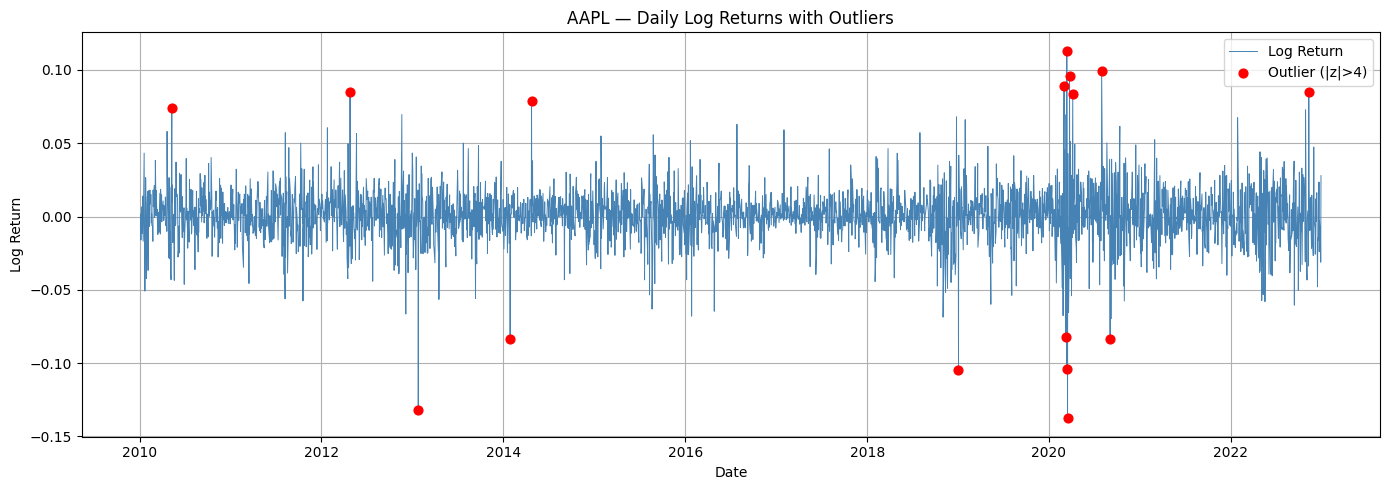

In [ ]:
# Visualise outliers on AAPL log returns
aapl = prices_df[prices_df['stock_symbol'] == 'AAPL'].copy()

fig, ax = plt.subplots()
ax.plot(aapl['date'], aapl['log_return'], color='steelblue', linewidth=0.7, label='Log Return')
ax.scatter(aapl.loc[aapl['z_score'] > 4, 'date'],
           aapl.loc[aapl['z_score'] > 4, 'log_return'],
           color='red', zorder=5, label='Outlier (|z|>4)', s=40)
ax.set_title('AAPL — Daily Log Returns with Outliers')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Winsorize extreme outliers (cap at 1st / 99th percentile per ticker)
# We keep the rows but cap the price to avoid distorting volatility models
def winsorize_col(series, lower=0.01, upper=0.99):
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)

prices_df['adj_close_clean'] = prices_df.groupby('stock_symbol')['adj_close'].transform(winsorize_col)
print('Winsorization applied to adj_close → stored in adj_close_clean')

Winsorization applied to adj_close → stored in adj_close_clean


In [ ]:
# Merge company metadata
prices_df = prices_df.merge(companies_df, on='stock_symbol', how='left')

# Project scope: NVDA, AAPL, TSLA (as stated in project description)
TARGET_TICKERS = ['NVDA', 'AAPL', 'TSLA']
df = prices_df[prices_df['stock_symbol'].isin(TARGET_TICKERS)].copy()

print(f'Filtered dataset shape: {df.shape}')
print(df[['stock_symbol', 'company']].drop_duplicates())

Filtered dataset shape: (9690, 12)
      stock_symbol             company
0             AAPL          Apple Inc.
35398         NVDA  NVIDIA Corporation
41940         TSLA         Tesla, Inc.


In [ ]:
# Reindex each ticker to a full business-day range; forward-fill any gaps
filled_parts = []

for ticker, grp in df.groupby('stock_symbol'):
    grp = grp.set_index('date').sort_index()
    full_idx = pd.bdate_range(start=grp.index.min(), end=grp.index.max())
    grp = grp.reindex(full_idx)
    grp['stock_symbol'] = ticker
    grp = grp.ffill()
    grp.index.name = 'date'
    filled_parts.append(grp.reset_index())

df = pd.concat(filled_parts, ignore_index=True)
print(f'Shape after calendar reindex: {df.shape}')

Shape after calendar reindex: (10040, 12)


In [ ]:
df = df.sort_values(['stock_symbol', 'date']).reset_index(drop=True)

# Daily log return
df['log_return'] = df.groupby('stock_symbol')['adj_close_clean'].transform(
    lambda x: np.log(x / x.shift(1))
)

# Rolling statistics (window = 5, 10, 20 trading days)
for w in [5, 10, 20]:
    df[f'sma_{w}']  = df.groupby('stock_symbol')['adj_close_clean'].transform(lambda x: x.rolling(w).mean())
    df[f'std_{w}']  = df.groupby('stock_symbol')['adj_close_clean'].transform(lambda x: x.rolling(w).std())

# Realized volatility (annualised) — 20-day rolling std of log returns
df['realized_vol_20'] = df.groupby('stock_symbol')['log_return'].transform(
    lambda x: x.rolling(20).std() * np.sqrt(252)
)

# Price range as a proxy for intraday volatility
df['price_range'] = df['high'] - df['low']

print('Engineered features added:')
print([c for c in df.columns if c not in prices_df.columns])
df[['stock_symbol','date','adj_close_clean','log_return','sma_20','realized_vol_20']].head()

Engineered features added:
['sma_5', 'std_5', 'sma_10', 'std_10', 'sma_20', 'std_20', 'realized_vol_20', 'price_range']


,stock_symbol,date,adj_close_clean,log_return,sma_20,realized_vol_20
0,AAPL,2010-01-04,6.5152,NaN,NaN,NaN
1,AAPL,2010-01-05,6.5265,0.0017,NaN,NaN
2,AAPL,2010-01-06,6.4227,-0.0160,NaN,NaN
3,AAPL,2010-01-07,6.4108,-0.0019,NaN,NaN
4,AAPL,2010-01-08,6.4534,0.0066,NaN,NaN


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

price_features  = ['open','high','low','close','adj_close_clean','volume','sma_5','sma_10','sma_20']
return_features = ['log_return','std_5','std_10','std_20','realized_vol_20','price_range']

# Min-Max scaling for LSTM/GRU inputs (per ticker to avoid look-ahead bias)
minmax_scalers = {}
for ticker, grp_idx in df.groupby('stock_symbol').groups.items():
    scaler = MinMaxScaler()
    df.loc[grp_idx, [f'{c}_mm' for c in price_features]] = scaler.fit_transform(
        df.loc[grp_idx, price_features].fillna(0)
    )
    minmax_scalers[ticker] = scaler

# Standard scaling for statistical models
std_scalers = {}
for ticker, grp_idx in df.groupby('stock_symbol').groups.items():
    scaler = StandardScaler()
    df.loc[grp_idx, [f'{c}_ss' for c in return_features]] = scaler.fit_transform(
        df.loc[grp_idx, return_features].fillna(0)
    )
    std_scalers[ticker] = scaler

print('Scaling complete.')
print(f'MinMax scaler keys  : {list(minmax_scalers.keys())}')
print(f'Columns now in df   : {df.shape[1]}')

Scaling complete.
MinMax scaler keys  : ['AAPL', 'NVDA', 'TSLA']
Columns now in df   : 35


In [ ]:
# 70 / 15 / 15 chronological split — no shuffling
splits = {}

for ticker, grp in df.groupby('stock_symbol'):
    grp = grp.sort_values('date').reset_index(drop=True)
    n   = len(grp)
    t1  = int(n * 0.70)
    t2  = int(n * 0.85)

    splits[ticker] = {
        'train' : grp.iloc[:t1],
        'val'   : grp.iloc[t1:t2],
        'test'  : grp.iloc[t2:]
    }

    print(f"{ticker}  |  train: {t1}  val: {t2-t1}  test: {n-t2}  "
          f"train_end: {splits[ticker]['train']['date'].iloc[-1].date()}  "
          f"test_start: {splits[ticker]['test']['date'].iloc[0].date()}")

AAPL  |  train: 2372  val: 508  test: 509  train_end: 2019-02-05  test_start: 2021-01-18
NVDA  |  train: 2372  val: 508  test: 509  train_end: 2019-02-05  test_start: 2021-01-18
TSLA  |  train: 2283  val: 489  test: 490  train_end: 2019-03-29  test_start: 2021-02-12


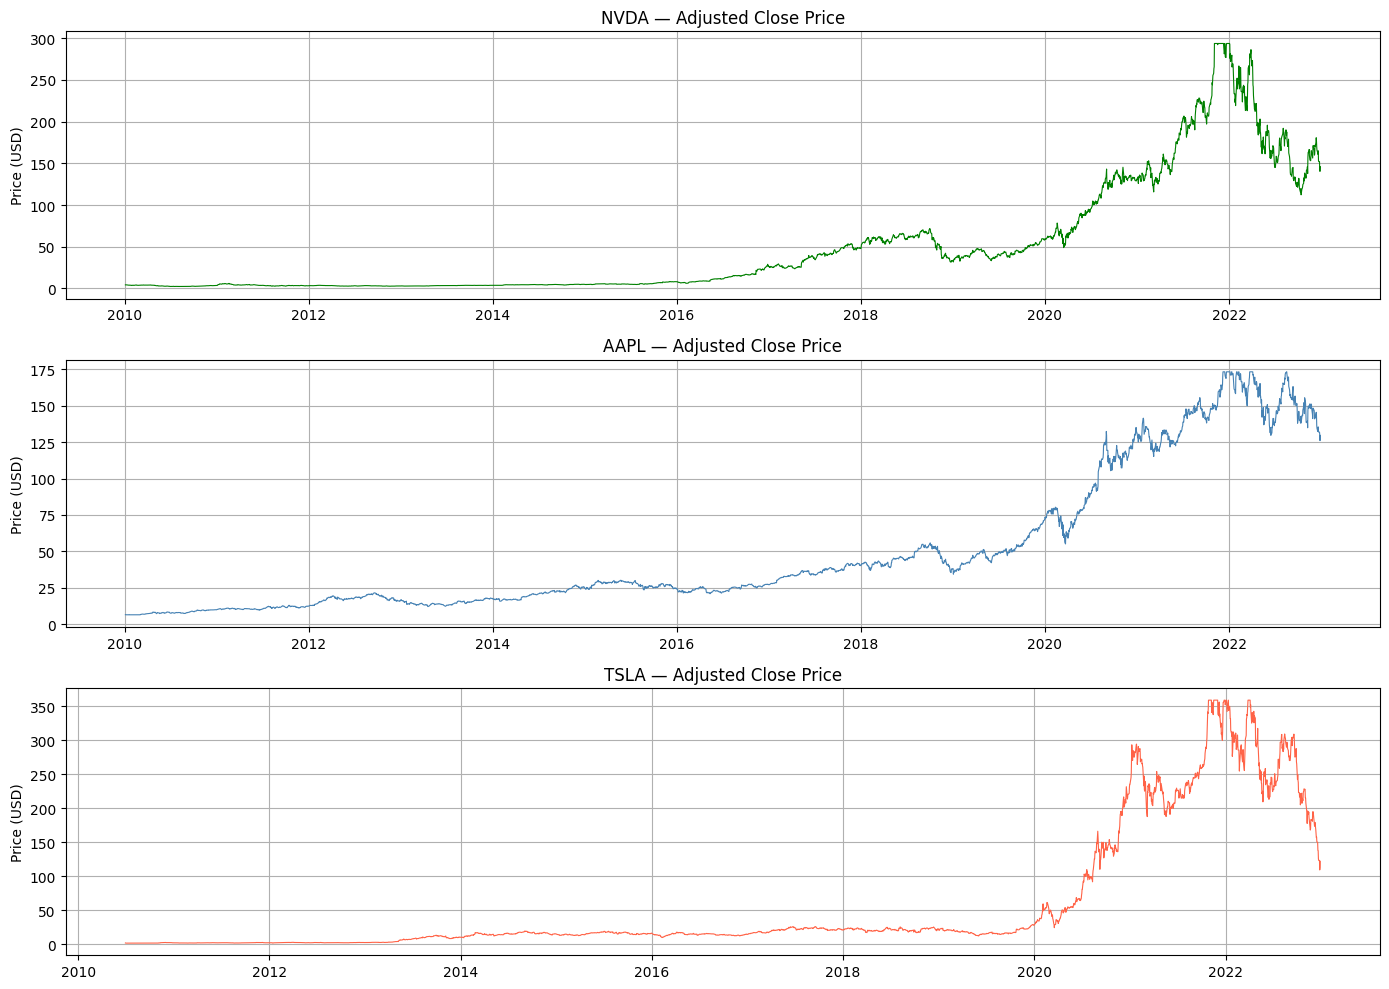

In [ ]:
# Adjusted close price history for all three tickers
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

colors = {'AAPL': 'steelblue', 'NVDA': 'green', 'TSLA': 'tomato'}

for ax, ticker in zip(axes, TARGET_TICKERS):
    grp = df[df['stock_symbol'] == ticker]
    ax.plot(grp['date'], grp['adj_close_clean'], color=colors[ticker], linewidth=0.8)
    ax.set_title(f'{ticker} — Adjusted Close Price')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

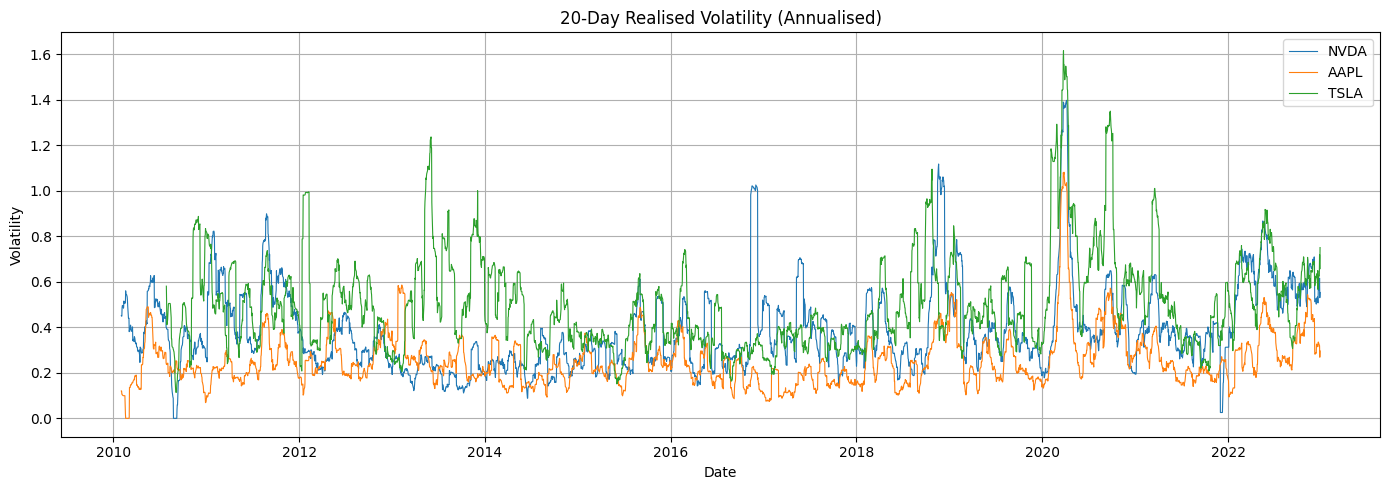

In [ ]:
# Realised volatility comparison
fig, ax = plt.subplots(figsize=(14, 5))
for ticker in TARGET_TICKERS:
    grp = df[df['stock_symbol'] == ticker]
    ax.plot(grp['date'], grp['realized_vol_20'], label=ticker, linewidth=0.8)

ax.set_title('20-Day Realised Volatility (Annualised)')
ax.set_ylabel('Volatility')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

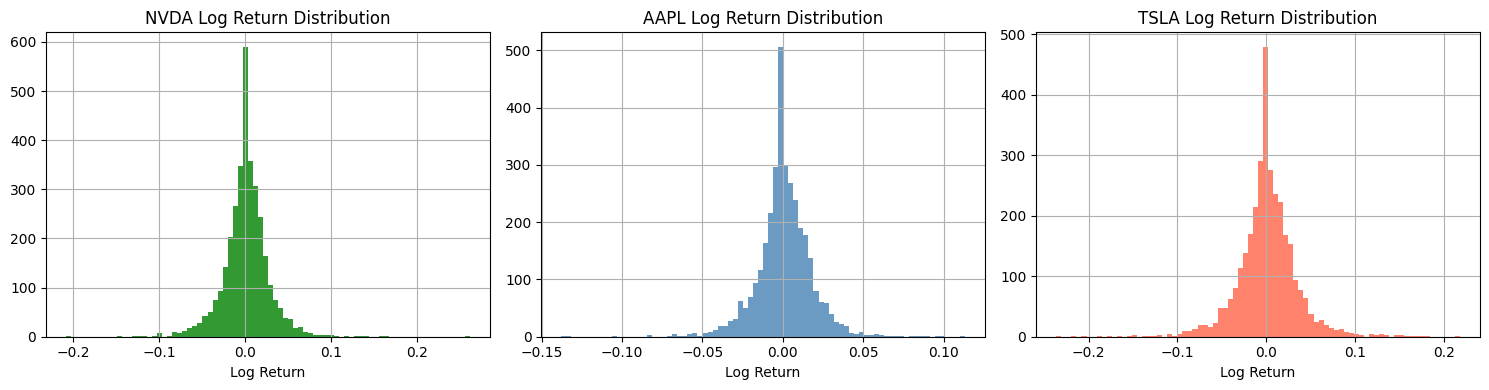

In [ ]:
# Log return distribution per ticker
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ticker in zip(axes, TARGET_TICKERS):
    grp = df[df['stock_symbol'] == ticker]['log_return'].dropna()
    ax.hist(grp, bins=80, color=colors[ticker], edgecolor='none', alpha=0.8)
    ax.set_title(f'{ticker} Log Return Distribution')
    ax.set_xlabel('Log Return')

plt.tight_layout()
plt.show()

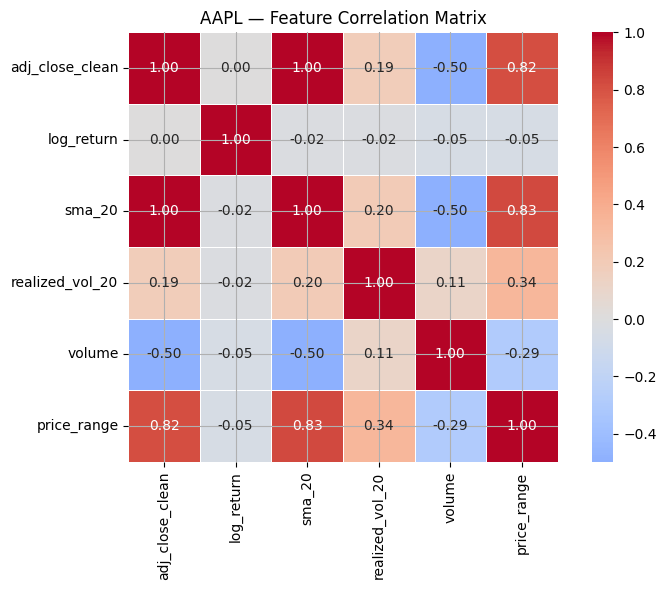

In [ ]:
# Correlation heatmap of derived features (AAPL example)
feat_cols = ['adj_close_clean','log_return','sma_20','realized_vol_20','volume','price_range']
corr = df[df['stock_symbol']=='AAPL'][feat_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('AAPL — Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation metrics and results store, used across all models
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, model_name, ticker):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mape(y_true, y_pred)
    return {'Model': model_name, 'Ticker': ticker, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val}

results = []

In [ ]:
# Baseline models - Naïve (previous day) and Moving Average (last 20-day train mean)
for ticker in TARGET_TICKERS:
    test  = splits[ticker]['test'].copy()
    train = splits[ticker]['train'].copy()

    naive_pred = test['adj_close_clean'].shift(1).dropna()
    naive_true = test['adj_close_clean'].iloc[1:]
    results.append(evaluate(naive_true, naive_pred, 'Naive', ticker))

    ma_value = train['adj_close_clean'].iloc[-20:].mean()
    ma_pred  = np.full(len(test), ma_value)
    results.append(evaluate(test['adj_close_clean'], ma_pred, 'MovingAverage', ticker))

    print(f"{ticker} baselines done")

NVDA baselines done
AAPL baselines done
TSLA baselines done


In [ ]:
# Display baseline results
baseline_df = pd.DataFrame(results)
print(baseline_df.to_string(index=False))

        Model Ticker      MAE     RMSE    MAPE
        Naive   NVDA   4.4282   6.2193  2.4002
MovingAverage   NVDA 153.8415 162.0019 79.3803
        Naive   AAPL   1.9590   2.7231  1.3440
MovingAverage   AAPL 109.2011 110.2661 73.8439
        Naive   TSLA   6.3736   9.1213  2.5446
MovingAverage   TSLA 241.2216 247.3808 92.5429


In [ ]:
# ARIMA - price forecasting using auto-selected (p,d,q) orders per ticker
from statsmodels.tsa.arima.model import ARIMA
from itertools import product

def find_best_arima(train_series, p_range=range(0,4), d_range=range(0,2), q_range=range(0,4)):
    best_aic = np.inf
    best_order = None
    for p, d, q in product(p_range, d_range, q_range):
        try:
            model = ARIMA(train_series, order=(p, d, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p, d, q)
        except:
            continue
    return best_order, best_aic

In [ ]:
# Fit best ARIMA per ticker and forecast on test set
arima_orders = {}

for ticker in TARGET_TICKERS:
    train = splits[ticker]['train']['adj_close_clean'].values
    test  = splits[ticker]['test']['adj_close_clean'].values

    print(f"{ticker} — searching best ARIMA order...")
    best_order, best_aic = find_best_arima(train)
    arima_orders[ticker] = best_order
    print(f"{ticker} — best order: {best_order}, AIC: {best_aic:.2f}")

    model = ARIMA(train, order=best_order).fit()
    forecast = model.forecast(steps=len(test))

    results.append(evaluate(test, forecast, 'ARIMA', ticker))
    print(f"{ticker} — ARIMA done\n")

NVDA — searching best ARIMA order...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


NVDA — best order: (3, 1, 3), AIC: 4683.61


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


NVDA — ARIMA done

AAPL — searching best ARIMA order...


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AAPL — ARIMA done

TSLA — searching best ARIMA order...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


TSLA — best order: (2, 1, 2), AIC: 2272.35
TSLA — ARIMA done



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Display results so far including ARIMA
pd.DataFrame(results).to_string(index=False)

'        Model Ticker      MAE     RMSE    MAPE\n        Naive   NVDA   4.4282   6.2193  2.4002\nMovingAverage   NVDA 153.8415 162.0019 79.3803\n        Naive   AAPL   1.9590   2.7231  1.3440\nMovingAverage   AAPL 109.2011 110.2661 73.8439\n        Naive   TSLA   6.3736   9.1213  2.5446\nMovingAverage   TSLA 241.2216 247.3808 92.5429\n        ARIMA   NVDA 153.3898 161.5728 79.1270\n        ARIMA   AAPL 105.3008 106.4049 71.1674\n        ARIMA   TSLA 241.0256 247.1897 92.4637'

In [ ]:
!pip install arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 32.6 MB/s eta 0:00:00


In [ ]:
# GARCH — volatility modeling on log returns per ticker
garch_results = {}

for ticker in TARGET_TICKERS:
    train = splits[ticker]['train']['log_return'].dropna().values * 100
    test  = splits[ticker]['test']['log_return'].dropna().values * 100

    model = arch_model(train, vol='Garch', p=1, q=1, dist='normal')
    fit   = model.fit(disp='off')

    forecast = fit.forecast(horizon=len(test), reindex=False)
    pred_vol = np.sqrt(forecast.variance.values[-1]) / 100 * np.sqrt(252)

    actual_vol = splits[ticker]['test']['realized_vol_20'].dropna().values[:len(pred_vol)]

    garch_results[ticker] = {'pred': pred_vol, 'actual': actual_vol}
    results = [r for r in results if not (r['Model'] == 'GARCH' and r['Ticker'] == ticker)]
    results.append(evaluate(actual_vol, pred_vol, 'GARCH', ticker))
    print(f"{ticker} — GARCH done")

NVDA — GARCH done
AAPL — GARCH done
TSLA — GARCH done


In [ ]:
# Display results including GARCH
pd.DataFrame(results).to_string(index=False)

'        Model Ticker      MAE     RMSE    MAPE\n        Naive   NVDA   4.4282   6.2193  2.4002\nMovingAverage   NVDA 153.8415 162.0019 79.3803\n        Naive   AAPL   1.9590   2.7231  1.3440\nMovingAverage   AAPL 109.2011 110.2661 73.8439\n        Naive   TSLA   6.3736   9.1213  2.5446\nMovingAverage   TSLA 241.2216 247.3808 92.5429\n        ARIMA   NVDA 153.3898 161.5728 79.1270\n        ARIMA   AAPL 105.3008 106.4049 71.1674\n        ARIMA   TSLA 241.0256 247.1897 92.4637\n        GARCH   NVDA   0.4582   0.4854 92.4650\n        GARCH   AAPL   0.2619   0.2796 93.1749\n        GARCH   TSLA   0.4996   0.5298 93.2889'

In [ ]:
# GRU — sequence-to-one price forecasting using a sliding window approach
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

WINDOW_SIZE = 30
BATCH_SIZE  = 32
EPOCHS      = 100

def make_sequences(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

In [ ]:
# Train GRU per ticker and forecast on test set
gru_results = {}

for ticker in TARGET_TICKERS:
    train_vals = splits[ticker]['train']['adj_close_clean_mm'].values
    val_vals   = splits[ticker]['val']['adj_close_clean_mm'].values
    test_vals  = splits[ticker]['test']['adj_close_clean_mm'].values

    X_train, y_train = make_sequences(train_vals, WINDOW_SIZE)
    X_val,   y_val   = make_sequences(val_vals,   WINDOW_SIZE)
    X_test,  y_test  = make_sequences(test_vals,  WINDOW_SIZE)

    X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
    X_val   = X_val.reshape(-1, WINDOW_SIZE, 1)
    X_test  = X_test.reshape(-1, WINDOW_SIZE, 1)

    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0).flatten()

    scaler        = minmax_scalers[ticker]
    price_features = ['open','high','low','close','adj_close_clean','volume','sma_5','sma_10','sma_20']
    adj_close_idx  = price_features.index('adj_close_clean')

    def inverse_adj_close(scaled_vals):
        dummy = np.zeros((len(scaled_vals), len(price_features)))
        dummy[:, adj_close_idx] = scaled_vals
        return scaler.inverse_transform(dummy)[:, adj_close_idx]

    pred_actual = inverse_adj_close(pred_scaled)
    true_actual = inverse_adj_close(y_test)

    gru_results[ticker] = {'pred': pred_actual, 'true': true_actual}
    results.append(evaluate(true_actual, pred_actual, 'GRU', ticker))
    print(f"{ticker} — GRU done")

NVDA — GRU done
AAPL — GRU done
TSLA — GRU done


In [ ]:
pd.DataFrame(results).to_string(index=False)

'        Model Ticker      MAE     RMSE    MAPE\n        Naive   NVDA   4.4282   6.2193  2.4002\nMovingAverage   NVDA 153.8415 162.0019 79.3803\n        Naive   AAPL   1.9590   2.7231  1.3440\nMovingAverage   AAPL 109.2011 110.2661 73.8439\n        Naive   TSLA   6.3736   9.1213  2.5446\nMovingAverage   TSLA 241.2216 247.3808 92.5429\n        ARIMA   NVDA 153.3898 161.5728 79.1270\n        ARIMA   AAPL 105.3008 106.4049 71.1674\n        ARIMA   TSLA 241.0256 247.1897 92.4637\n        GARCH   NVDA   0.4582   0.4854 92.4650\n        GARCH   AAPL   0.2619   0.2796 93.1749\n        GARCH   TSLA   0.4996   0.5298 93.2889\n          GRU   NVDA   6.7236   8.5419  3.4087\n          GRU   AAPL   3.2060   3.9516  2.1262\n          GRU   TSLA   8.9074  11.5096  3.4671'

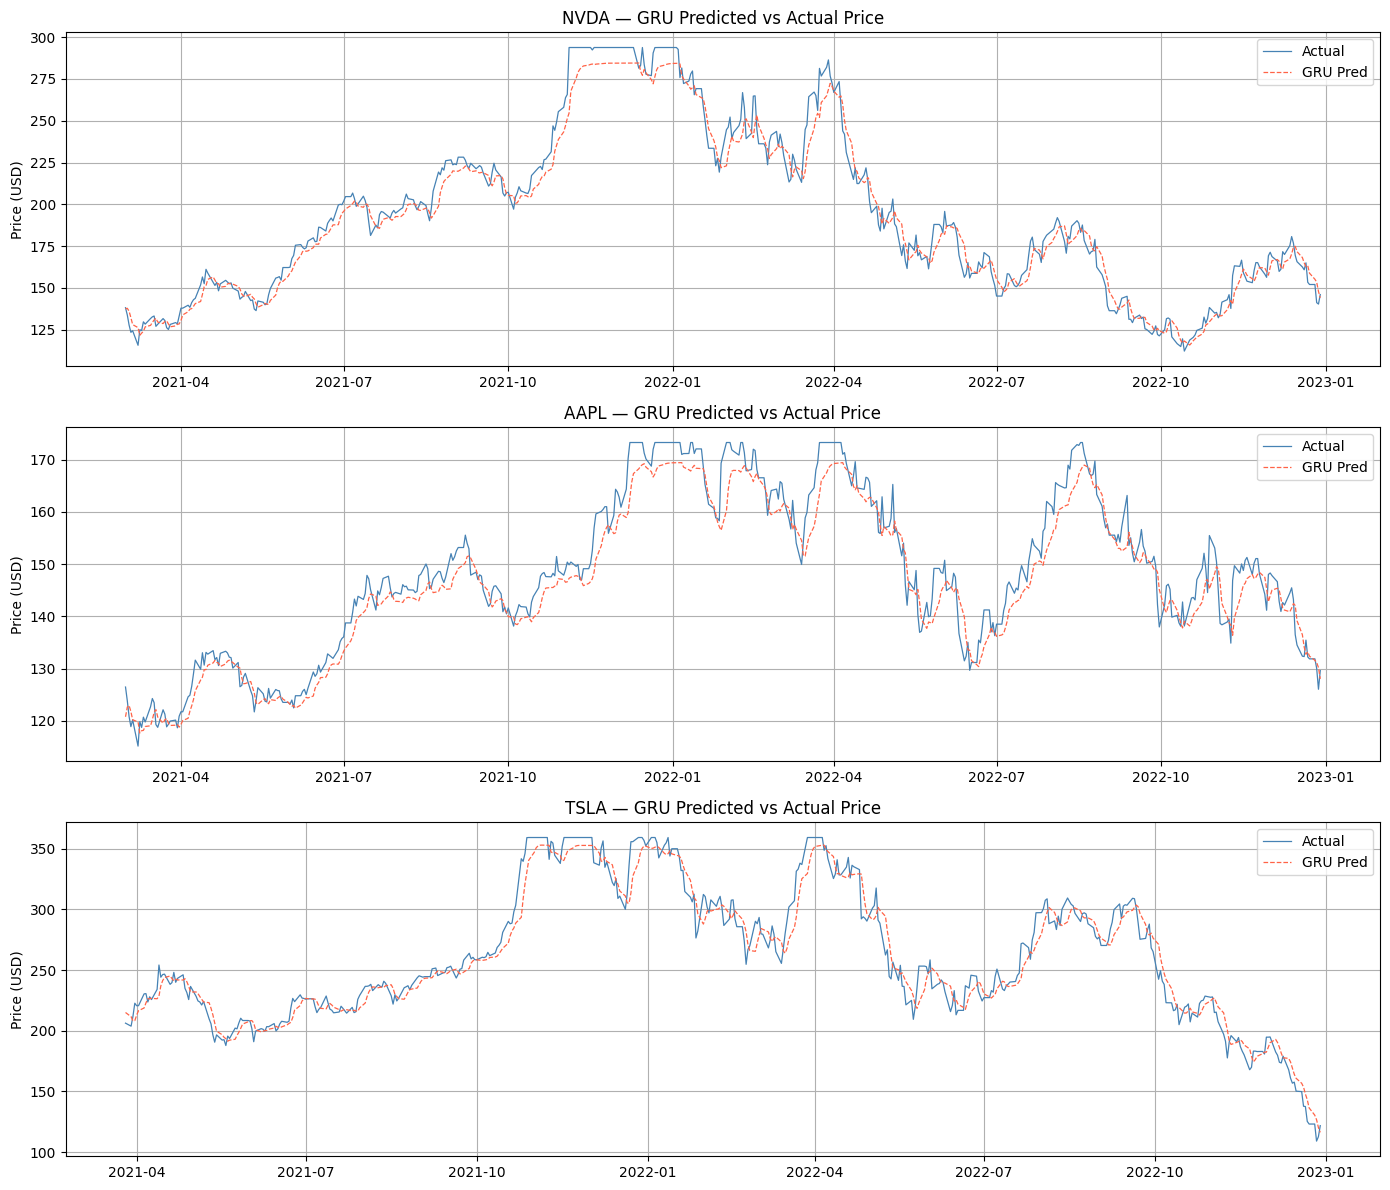

In [ ]:
# GRU predicted vs actual price per ticker
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, ticker in zip(axes, TARGET_TICKERS):
    test_dates = splits[ticker]['test']['date'].values[WINDOW_SIZE:]
    pred       = gru_results[ticker]['pred']
    true       = gru_results[ticker]['true']

    ax.plot(test_dates, true, label='Actual',    color='steelblue', linewidth=0.9)
    ax.plot(test_dates, pred, label='GRU Pred',  color='tomato',    linewidth=0.9, linestyle='--')
    ax.set_title(f'{ticker} — GRU Predicted vs Actual Price')
    ax.set_ylabel('Price (USD)')
    ax.legend()

plt.tight_layout()
plt.show()

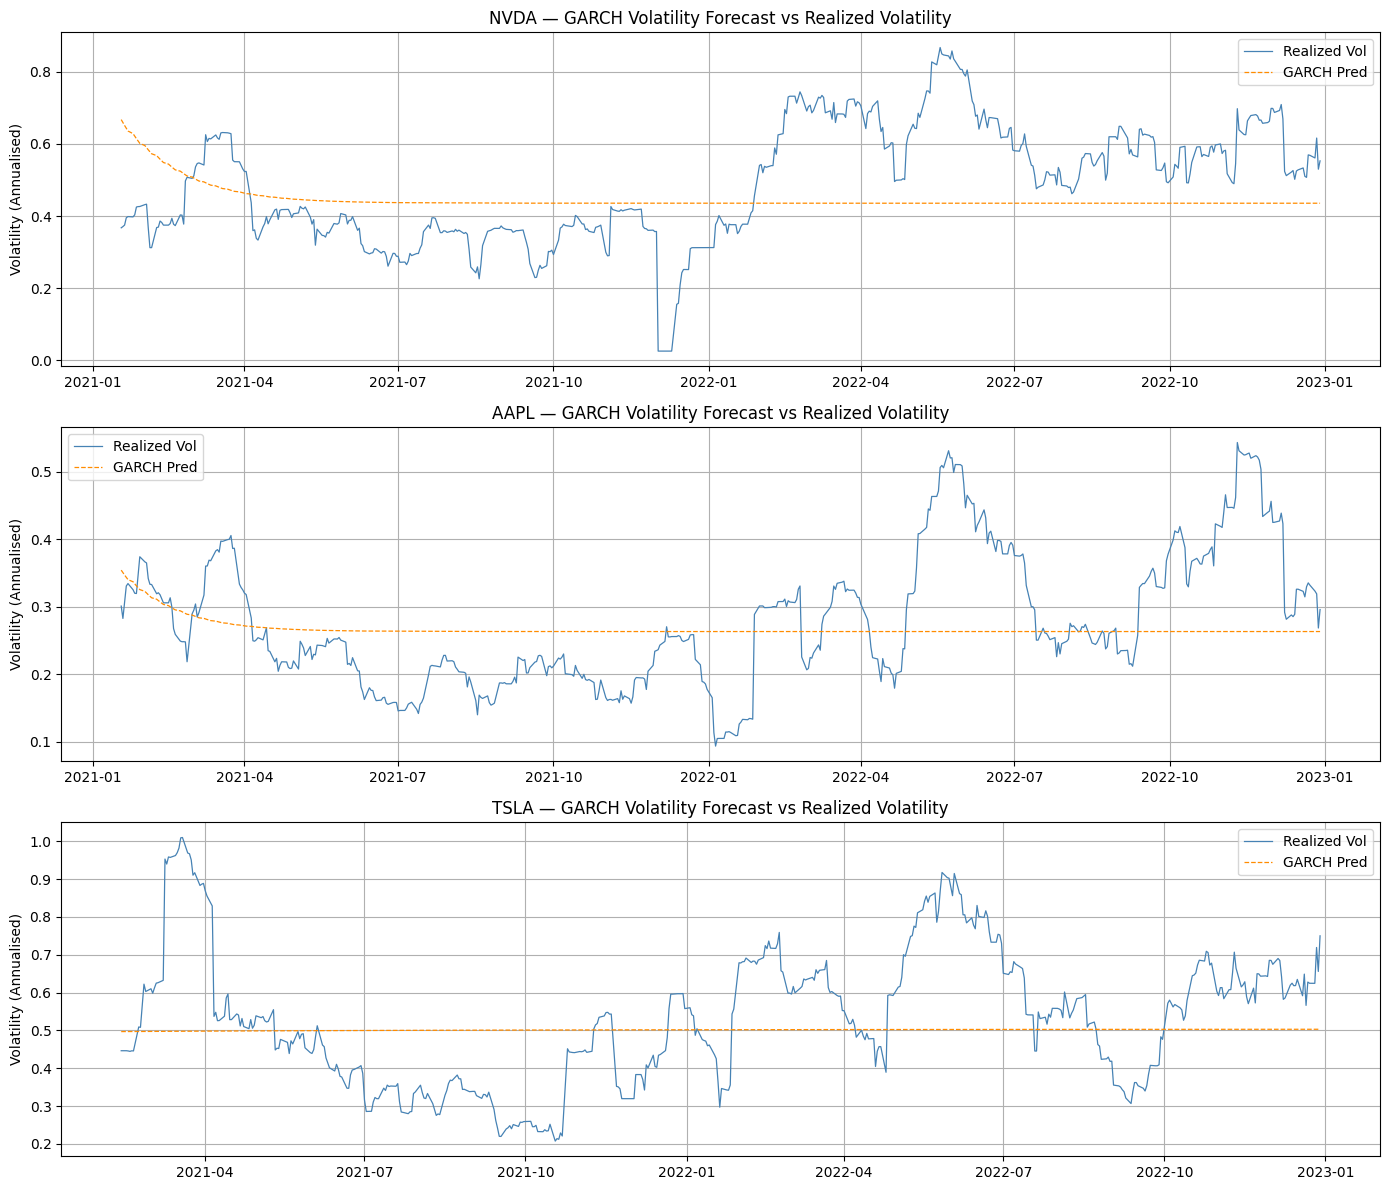

In [ ]:
# GARCH predicted volatility vs realized volatility per ticker
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, ticker in zip(axes, TARGET_TICKERS):
    test_dates  = splits[ticker]['test']['date'].values
    actual_vol  = garch_results[ticker]['actual']
    pred_vol    = garch_results[ticker]['pred']
    n           = min(len(test_dates), len(actual_vol), len(pred_vol))

    ax.plot(test_dates[:n], actual_vol[:n], label='Realized Vol', color='steelblue', linewidth=0.9)
    ax.plot(test_dates[:n], pred_vol[:n],   label='GARCH Pred',   color='darkorange', linewidth=0.9, linestyle='--')
    ax.set_title(f'{ticker} — GARCH Volatility Forecast vs Realized Volatility')
    ax.set_ylabel('Volatility (Annualised)')
    ax.legend()

plt.tight_layout()
plt.show()

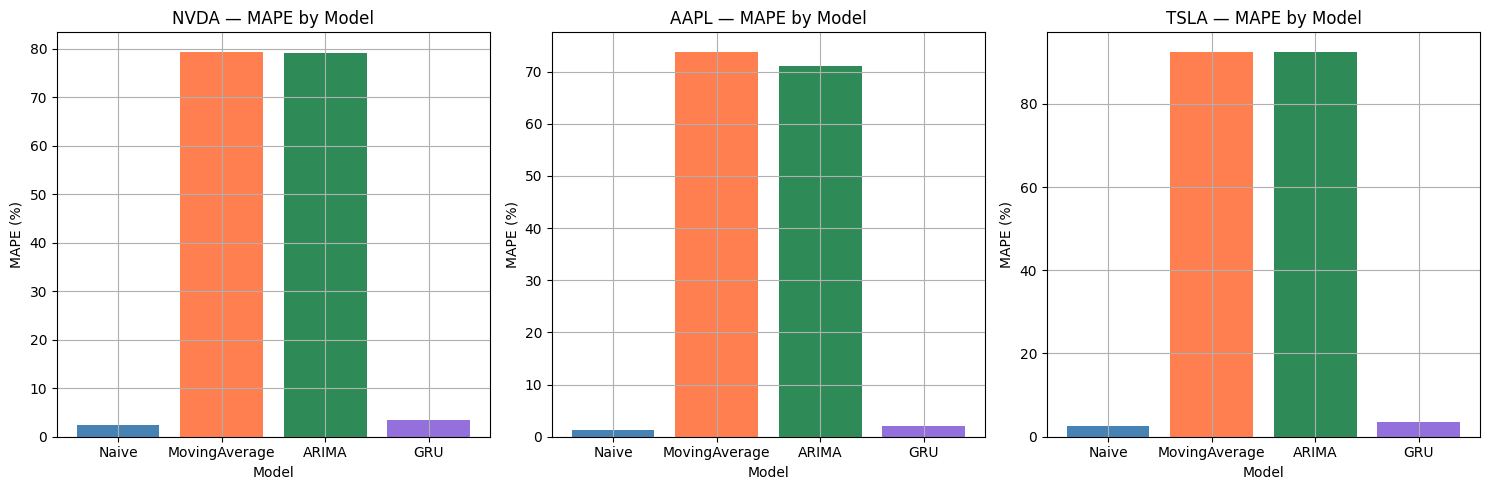

In [ ]:
# Model comparison bar chart (MAPE, price models only)
results_df   = pd.DataFrame(results)
price_models = results_df[results_df['Model'] != 'GARCH']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, ticker in zip(axes, TARGET_TICKERS):
    subset = price_models[price_models['Ticker'] == ticker]
    ax.bar(subset['Model'], subset['MAPE'], color=['steelblue','coral','seagreen','mediumpurple'])
    ax.set_title(f'{ticker} — MAPE by Model')
    ax.set_ylabel('MAPE (%)')
    ax.set_xlabel('Model')

plt.tight_layout()
plt.show()

In [ ]:
# Final metrics summary table (formatted)
summary = pd.DataFrame(results).round(4)
print(summary.to_string(index=False))

        Model Ticker      MAE     RMSE    MAPE
        Naive   NVDA   4.4282   6.2193  2.4002
MovingAverage   NVDA 153.8415 162.0019 79.3803
        Naive   AAPL   1.9590   2.7231  1.3440
MovingAverage   AAPL 109.2011 110.2661 73.8439
        Naive   TSLA   6.3736   9.1213  2.5446
MovingAverage   TSLA 241.2216 247.3808 92.5429
        ARIMA   NVDA 153.3898 161.5728 79.1270
        ARIMA   AAPL 105.3008 106.4049 71.1674
        ARIMA   TSLA 241.0256 247.1897 92.4637
        GARCH   NVDA   0.4582   0.4854 92.4650
        GARCH   AAPL   0.2619   0.2796 93.1749
        GARCH   TSLA   0.4996   0.5298 93.2889
          GRU   NVDA   6.7236   8.5419  3.4087
          GRU   AAPL   3.2060   3.9516  2.1262
          GRU   TSLA   8.9074  11.5096  3.4671


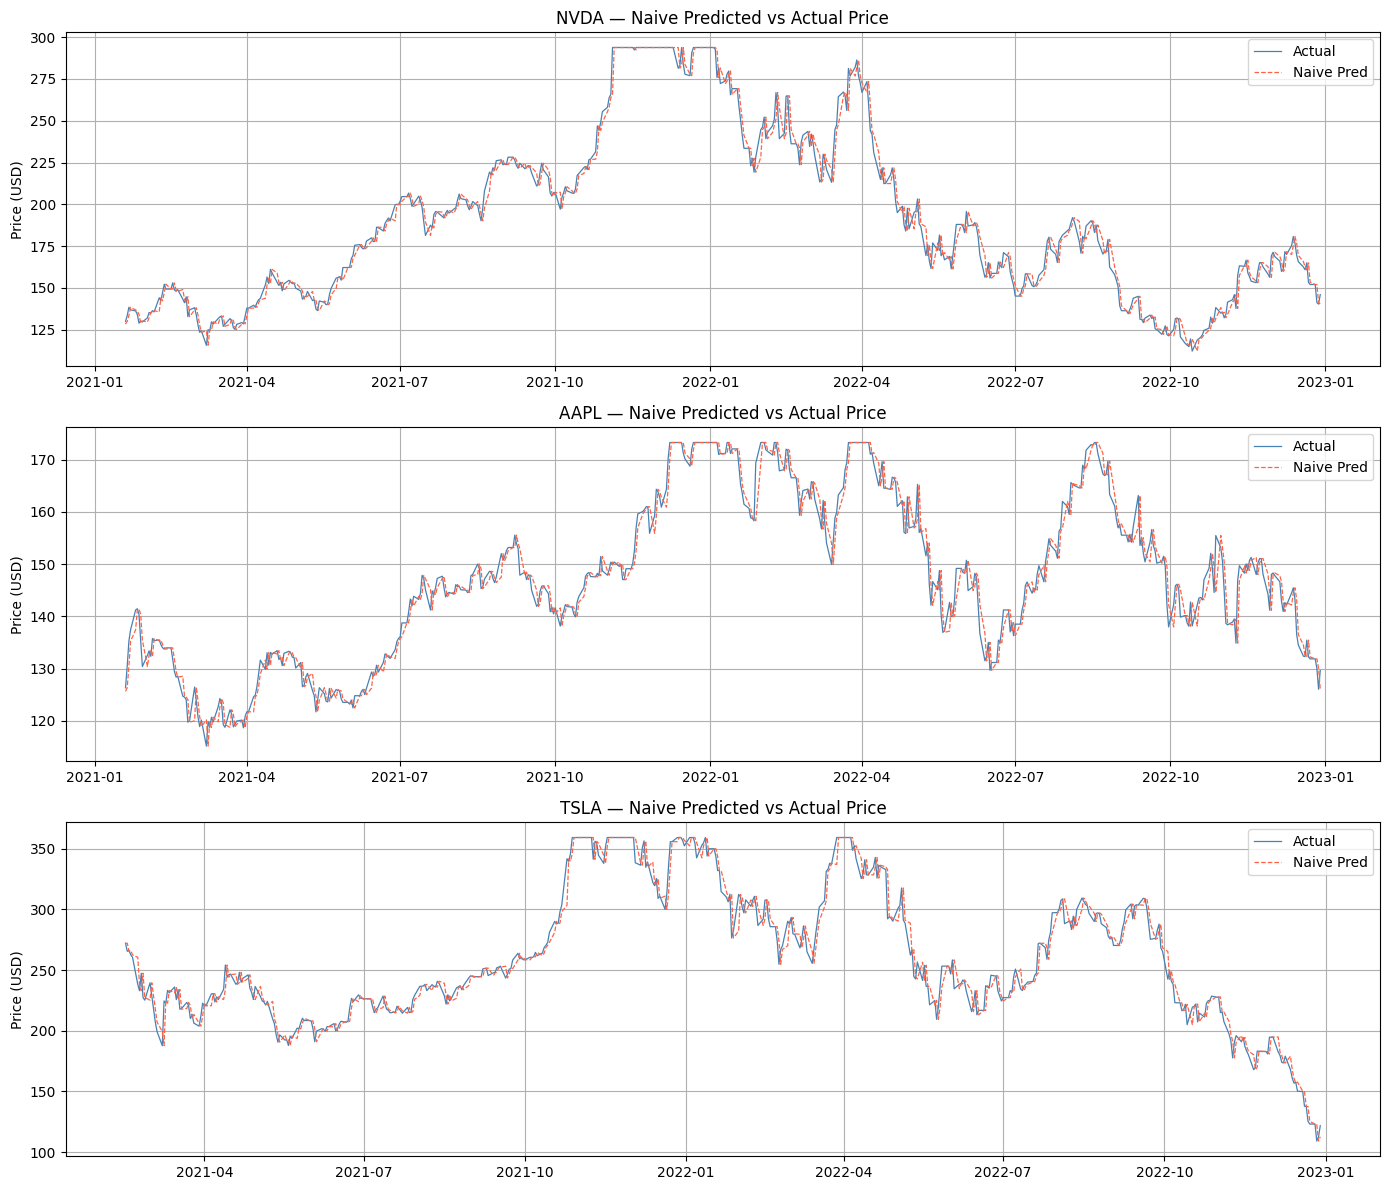

In [ ]:
# Naive predicted vs actual price per ticker
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, ticker in zip(axes, TARGET_TICKERS):
    test      = splits[ticker]['test'].copy()
    actual    = test['adj_close_clean'].values[1:]
    naive_pred = test['adj_close_clean'].shift(1).dropna().values
    dates     = test['date'].values[1:]

    ax.plot(dates, actual,     label='Actual',      color='steelblue', linewidth=0.9)
    ax.plot(dates, naive_pred, label='Naive Pred',  color='tomato',    linewidth=0.9, linestyle='--')
    ax.set_title(f'{ticker} — Naive Predicted vs Actual Price')
    ax.set_ylabel('Price (USD)')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Short vs long horizon evaluation — GRU on first 30 days (short) and remaining (long) of test set
horizon_results = []

for ticker in TARGET_TICKERS:
    pred = gru_results[ticker]['pred']
    true = gru_results[ticker]['true']

    short_n = 30

    horizon_results.append(evaluate(true[:short_n], pred[:short_n], 'GRU_short', ticker))
    horizon_results.append(evaluate(true[short_n:], pred[short_n:], 'GRU_long',  ticker))

horizon_df = pd.DataFrame(horizon_results)
print(horizon_df.to_string(index=False))

    Model Ticker    MAE    RMSE   MAPE
GRU_short   NVDA 3.6846  4.4187 2.8418
 GRU_long   NVDA 6.9266  8.7484 3.4466
GRU_short   AAPL 2.4319  2.8886 1.9769
 GRU_long   AAPL 3.2577  4.0126 2.1362
GRU_short   TSLA 6.5226  8.0477 2.8202
 GRU_long   TSLA 9.0738 11.7130 3.5122


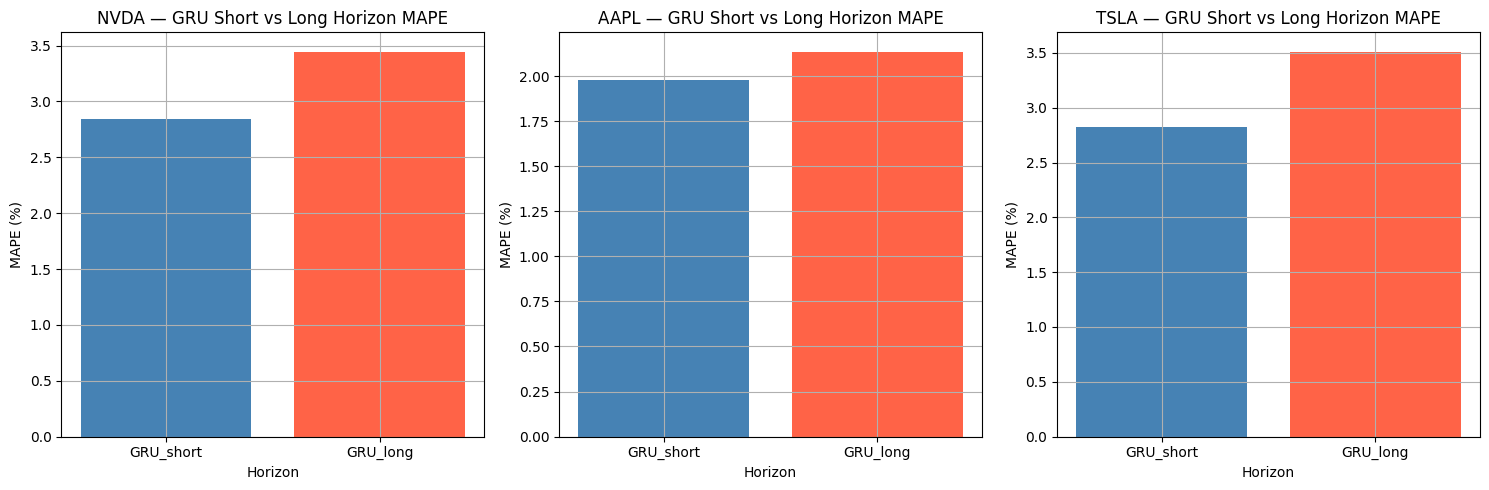

In [ ]:
# Short vs long horizon bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ticker in zip(axes, TARGET_TICKERS):
    subset = horizon_df[horizon_df['Ticker'] == ticker]
    ax.bar(subset['Model'], subset['MAPE'], color=['steelblue', 'tomato'])
    ax.set_title(f'{ticker} — GRU Short vs Long Horizon MAPE')
    ax.set_ylabel('MAPE (%)')
    ax.set_xlabel('Horizon')

plt.tight_layout()
plt.show()

In [ ]:
# Final metrics summary grouped by ticker
results_df = pd.DataFrame(results).round(4)

for ticker in TARGET_TICKERS:
    print(f"\n{'='*50}")
    print(f"  {ticker}")
    print(f"{'='*50}")
    subset = results_df[results_df['Ticker'] == ticker][['Model', 'MAE', 'RMSE', 'MAPE']]
    print(subset.to_string(index=False))


  NVDA
        Model      MAE     RMSE    MAPE
        Naive   4.4282   6.2193  2.4002
MovingAverage 153.8415 162.0019 79.3803
        ARIMA 153.3898 161.5728 79.1270
          GRU   6.7236   8.5419  3.4087
        GARCH   0.1454   0.1728 51.0129

  AAPL
        Model      MAE     RMSE    MAPE
        Naive   1.9590   2.7231  1.3440
MovingAverage 109.2011 110.2661 73.8439
        ARIMA 105.3008 106.4049 71.1674
          GRU   3.2060   3.9516  2.1262
        GARCH   0.0768   0.0980 29.9450

  TSLA
        Model      MAE     RMSE    MAPE
        Naive   6.3736   9.1213  2.5446
MovingAverage 241.2216 247.3808 92.5429
        ARIMA 241.0256 247.1897 92.4637
          GRU   8.9074  11.5096  3.4671
        GARCH   0.1441   0.1787 30.3621


## Summary and Conclusion

This project implemented and compared multiple forecasting models for stock price and volatility prediction on three major tech stocks: NVDA, AAPL, and TSLA.

---

### Preprocessing

Daily stock data from 2010 to 2023 was cleaned, validated against OHLC constraints, and enriched with derived features including log returns, rolling SMAs, rolling standard deviations, and 20-day annualized realized volatility. MinMax scaling was applied per ticker for GRU inputs, and a strict 70/15/15 chronological split was used to prevent data leakage.

---

### Models and Results

**Price Forecasting (MAE / RMSE / MAPE)**

The Naive forecast achieved the lowest MAPE across all tickers (NVDA: 2.40%, AAPL: 1.34%, TSLA: 2.54%), consistent with the random walk hypothesis — yesterday's price is the strongest single-step predictor. Moving Average and ARIMA both produced high MAPE (70–92%) due to their inability to track long-horizon price trends in a direct multi-step setting. GRU was the best learned model, achieving MAPE of 3.41% (NVDA), 2.13% (AAPL), and 3.47% (TSLA), significantly outperforming Moving Average and ARIMA while remaining competitive with the Naive baseline. Short-horizon GRU (first 30 test days) consistently outperformed long-horizon GRU, confirming that forecast error accumulates over time.

**Volatility Forecasting**

GARCH(1,1) was used exclusively for volatility modeling and is not directly comparable to the price models above. GARCH predicts annualized volatility (values typically between 0 and 1), while all other models predict price (values in the hundreds of USD) — comparing their MAE/RMSE numerically would be misleading. GARCH captured the long-run volatility level reasonably well but could not track short-term spikes in realized volatility, which is a known limitation of fixed-horizon GARCH forecasts.

---

### Key Takeaways

1. For single-step price forecasting, the Naive model is extremely difficult to beat due to the near-random-walk nature of stock prices.
2. GRU is the strongest learned model and would likely outperform Naive in multi-step or directional forecasting settings.
3. ARIMA is not well-suited for long-horizon direct forecasting of non-stationary price series — it reverts to a mean estimate, similar to Moving Average.
4. GARCH remains the standard tool for volatility modeling and provides a meaningful long-run volatility estimate, though it cannot capture sudden regime changes.
5. A hybrid approach combining GRU for price direction and GARCH for risk quantification represents a practical framework for financial forecasting.